# Notebook 5 — Fault detection with a *healthy digital shadow* EKF

**The idea.** Build the EKF as a **healthy digital shadow**: estimate $T,pH,DO$ from their
*healthy* ODEs *inside* predict (healthy heater, pH-PI pumps, Van't Riet $k_La$) and **do not
feed the real environment in**. Ethanol is the *only* measurement. The shadow then always
believes $T=30,\ pH=5,\ DO\approx100$; when the real reactor is faulted, its growth/ethanol
diverge from the healthy prediction, so the **ethanol innovation itself carries the fault
signal** → a simple innovation-mean detector raises an alarm.


State (8): $[X,\;G,\;E,\;\mu_{\max,G},\;\mu_{\max,E},\;T,\;pH,\;DO]$. Measurement: **ethanol only**.



## 0 · Imports and notebook configuration

Run once per kernel restart.

In [1]:
# ─────────────────────────────────────────────────────────────────────────
# CELL 0 — Imports and notebook configuration
# The source working notebook imported matplotlib/contextlib part-way down;
# hoisting them here is what makes restart-and-run-all reproduce the figures.
# ─────────────────────────────────────────────────────────────────────────
import contextlib
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.grid'        : True,
    'grid.alpha'       : 0.35,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 110,
    'savefig.dpi'      : 110,
})

FIGDIR = 'figures'          # all figures land here, as in notebooks 1-5
print("libraries loaded")

libraries loaded


## 1 · Parameters, growth modifiers, kinetics

In [2]:
import warnings
import numpy as np

# ── Parameters (bioreactor_ui/backend/core.py :: DEFAULTS) ────────────────────
KG, KE = 0.1, 0.1
Ygx, Yge, Yex = 0.15, 0.34, 0.43
V, rhoCp, Y_QX = 1.35, 4180.0, 12000.0
T_set, T_amb, K_p, Q_max, UA = 30.0, 22.0, 50.0, 630.0, 18.0
pH_set = 5.0
pH_min, pH_opt, pH_max = 2.5, 4.7, 8.0        # 'robust' profile, shared with nb 7 + the app
alpha_meta, alpha_pump = 0.4, 0.2563          # *** CONFIRM *** (acidogenesis / buffer)
F_A_MAX, F_B_MAX = 210.0, 210.0
Kc_pump, Ki_pump = 120.0, 250.0               # *** CONFIRM *** (PI pH gains)
DT_CTRL_S = 2.0
# DO / kLa (Van't Riet, Minifors 2 DN90) — see DO_kLa_proposal.md
N_rpm_0, Q_air_0 = 500.0, 3.5
# kLa COMPUTED from the Minifors 2 geometry (Van't Riet), not an assumed anchor —
# the same number nb 4, nb 7 and bioreactor_ui use. Comes out at 44.8 1/h.
D_vessel_m, D_imp_frac, N_power, N_impellers = 0.090, 1/3, 5.0, 2
rho_broth, Pg_P0 = 1000.0, 0.5
VR_C, VR_a, VR_b = 0.002, 0.7, 0.2
def compute_kLa(N_rpm=N_rpm_0, Q_air_Lmin=Q_air_0, V_L=V):
    A_cross = np.pi/4 * D_vessel_m**2
    D_imp   = D_vessel_m * D_imp_frac
    v_s     = (Q_air_Lmin/1000.0/60.0) / A_cross
    P0      = N_impellers * N_power * rho_broth * (N_rpm/60.0)**3 * D_imp**5
    Pg_V    = (Pg_P0 * P0) / (V_L/1000.0)
    return 0.0 if (Pg_V <= 0 or v_s <= 0) else VR_C*(Pg_V**VR_a)*(v_s**VR_b)*3600.0
kLa_0 = compute_kLa()                          # healthy kLa [1/h] from the vessel
DO_star, qO2_max, K_O_pct, DO0, DO_sat_mgL = 100.0, 8.0, 3.0, 100.0, 6.7   # qO2_max *** CONFIRM ***

T_FINAL   = 10.0
DT_CTRL_H = DT_CTRL_S / 3600.0                 # ground-truth integration tick [h]
DT_MEAS   = 5.0 / 60.0                          # ethanol sample cadence [h]
DT_PRED   = 1.0 / 60.0                          # EKF predict substep [h]
X0, G0, E0, muG0, muE0 = 2.5, 5.0, 0.0, 0.15, 0.08

# ── The two Rosso forms — NOT interchangeable ─────────────────────────
# n = 2 (the CTMI) is the cardinal TEMPERATURE model. Its denominator has a root
# INSIDE (v_min, v_max) whenever the optimum sits below the midpoint of the
# window, and a clip to [0, 1] hides that pole as a STEP FUNCTION. That is what
# this notebook used to do to f_pH on the triple (3.0, 5.0, 12.0): arms of 2 and
# 7, pole at pH 3.833, so f_pH returned exactly 0 below it and exactly 1 above.
# It carried no gradient at all — it could say "dead" or "fine" and nothing in
# between, which makes a pH fault either invisible or instantly lethal and
# nothing else. pH therefore uses n = 1, which has no interior pole and handles
# asymmetric arms. `_assert_monotone` below is the regression test; it FAILS on
# the old triple. (Same code as bioreactor_ui/backend/core.py and
# 7_mmae_fault_isolation.ipynb A.3.)
PHI_FLOOR = 1e-6      # never return a hard zero: that hands the EKF a zero
                      # Jacobian and the filter can never correct its way back.


def _rosso_n2(u, v_min, v_opt, v_max):
    """Rosso (1993) CTMI, n = 2 — the cardinal TEMPERATURE model."""
    if u <= v_min or u >= v_max:
        return 0.0
    num = (u - v_max) * (u - v_min) ** 2
    den = (v_opt - v_min) * ((v_opt - v_min) * (u - v_opt)
                             - (v_opt - v_max) * (v_opt + v_min - 2 * u))
    return 0.0 if abs(den) < 1e-12 else num / den


def _rosso_n1(u, v_min, v_opt, v_max):
    """Rosso n = 1 — the pH form. No interior pole, asymmetric arms handled."""
    if u <= v_min or u >= v_max:
        return 0.0
    num = (u - v_min) * (u - v_max)
    den = num - (u - v_opt) ** 2
    return 0.0 if abs(den) < 1e-12 else num / den


def _anchored(raw, v, v_min, v_opt, v_max, anchor):
    """Re-anchor so f(anchor) == 1, clipping AFTER normalisation (only below).


    Clipping to [0, 1] BEFORE dividing by f(anchor) truncates the physically
    correct f > 1 that arises when the reactor sits closer to the optimum than
    the anchor does (pH_opt 4.7 vs pH_set 5.0).
    """
    a = raw(anchor, v_min, v_opt, v_max)
    if a <= 0.0:
        raise ValueError(f"anchor {anchor} outside the viable window "
                         f"({v_min}, {v_max}): f(anchor) = {a}")
    return float(np.clip(raw(v, v_min, v_opt, v_max) / a, PHI_FLOOR, None))


def _assert_monotone(f, lo, hi, name, n=300):
    """Every modifier must rise monotonically towards its optimum.

    A Rosso denominator that changes sign inside the window is invisible in the
    output — the clip presents the pole as a clean 0/1 step — so nothing but a
    shape check catches it.
    """
    grid = np.linspace(lo, hi, n)
    curve = np.array([f(v) for v in grid])
    bad = np.where(np.diff(curve) < -1e-9)[0]
    if len(bad):
        raise ValueError(
            f"{name} is not monotone rising on [{lo}, {hi}]: {len(bad)} violations, "
            f"first at {grid[bad[0]]:.3f}. A Rosso denominator has changed sign "
            f"and the clip is hiding the pole as a step function.")
    return curve


def make_cardinal_modifier(v_min, v_opt, v_max, anchor, n=2):
    """Re-anchored Rosso modifier. n = 2 for temperature, n = 1 for pH."""
    raw = _rosso_n1 if n == 1 else _rosso_n2
    return lambda v: _anchored(raw, v, v_min, v_opt, v_max, anchor)

# Strain cardinal-T is an ORGANISM property -> shared by plant AND shadow.
# Under healthy T=30, f_T=1 for either strain; under a heater fault (T->22) the
# sensitive strain's growth collapses -> strong ethanol signal, the robust strain barely reacts.
STRAIN_CARDINALS = {'robust': (5.0, 30.0, 40.0), 'sensitive': (27.0, 30.0, 33.0)}
def set_strain(name):
    global f_T
    tmn, top, tmx = STRAIN_CARDINALS[name]
    f_T = make_cardinal_modifier(tmn, top, tmx, T_set)

f_T  = make_cardinal_modifier(*STRAIN_CARDINALS['robust'], T_set)   # default
# pH arms are asymmetric -> n = 1, the pole-free form; anchored at the SETPOINT.
f_pH = make_cardinal_modifier(pH_min, pH_opt, pH_max, pH_set, n=1)
_assert_monotone(f_pH, pH_min + 1e-6, pH_opt, 'f_pH')
_assert_monotone(f_T,  5.0 + 1e-6,    30.0,   'f_T')

# Oxygen limitation: re-anchored Monod (more O2 never hurts below toxic levels)
_do_anchor = DO_star / (K_O_pct + DO_star)
def f_DO(DO):
    DO = max(DO, 0.0)
    return max(0.0, min(1.0, (DO / (K_O_pct + DO)) / _do_anchor))

def kLa_scaled(N_rpm, Q_air_Lmin):             # fault kLa via robust Van't Riet exponents
    return kLa_0 * (N_rpm / N_rpm_0) ** 2.1 * (Q_air_Lmin / Q_air_0) ** 0.2

def monod_rates(X, G, E, m1, m2, phi):
    if m1 > 1e-9:
        muG = m1 * G / (KG + G) * phi
        supp = 1.0 - muG / m1                   # diauxic suppression (~0 while glucose high)
    else:
        muG, supp = 0.0, 1.0
    muE = (m2 * E / (KE + E) * supp * phi) if m2 > 1e-9 else 0.0
    return muG, muE


# ─────────────────────────────────────────────────────────────────────────
# IS THE SETPOINT ITSELF ANY GOOD?  (ported from bioreactor_ui/backend/plant.py)
#
# `_anchored` normalises so f(setpoint) == 1, which makes the anchored modifier
# structurally incapable of answering that question — it measures distance FROM
# the setpoint, not the quality OF it. The un-anchored value, relative to the
# organism's true optimum, is the one that does.
#
# Why it matters: a setpoint parked in a dead corner of the cardinal window
# leaves the HEALTHY reference crippled, and that inverts the whole detector — a
# fault which moves the variable back TOWARDS the optimum then makes the culture
# grow BETTER than "healthy", and no threshold reads that correctly. Observed in
# the app with pH_set = pH_max = 5.0: healthy X_end 2.50 (no growth at all),
# base-pump-off X_end 4.00, and no alarm. The anchor raise below catches the
# exactly-on-the-boundary case; this catches the near-boundary one, which is
# just as wrong and completely silent.
# ─────────────────────────────────────────────────────────────────────────
def absolute_modifier(v, v_min, v_opt, v_max, n=2):
    """The modifier at `v` relative to the organism's TRUE optimum, un-anchored."""
    raw = _rosso_n1 if n == 1 else _rosso_n2
    peak = raw(v_opt, v_min, v_opt, v_max)
    return 0.0 if peak < 1e-12 else raw(v, v_min, v_opt, v_max) / peak


def check_setpoint_quality(v_set, v_min, v_opt, v_max, n, name, floor=0.5):
    """Warn if holding at `v_set` already costs more than half the growth rate."""
    a = absolute_modifier(v_set, v_min, v_opt, v_max, n)
    if a < floor:
        warnings.warn(
            f"{name}: holding at {v_set} leaves the culture at {100*a:.0f} % of "
            f"its peak rate on cardinals ({v_min}, {v_opt}, {v_max}). The HEALTHY "
            f"reference is itself crippled, so a fault moving {name} back towards "
            f"the optimum will grow BETTER than 'healthy' and the detector reads "
            f"it backwards.", RuntimeWarning, stacklevel=2)
    return a

_ = check_setpoint_quality(pH_set, pH_min, pH_opt, pH_max, 1, 'pH')


## 2 · Plant — 8-state RHS + PI pH pumps  (ground truth, healthy *or* faulted)

In [3]:
def rhs8(y, F_A, F_B, kLa, heater_ok=True):
    """8-state RHS [X,G,E,mG,mE,T,pH,DO]; pumps + kLa held over a control tick.
    phi = f_T*f_pH*f_DO scales both growth rates. heater_ok=False models a dead heater."""
    X, G, E, m1, m2, T, pH, DO = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0); pH = max(pH, 1.0); DO = max(DO, 0.0)
    phi = f_T(T) * f_pH(pH) * f_DO(DO)
    muG, muE = monod_rates(X, G, E, m1, m2, phi)
    dX = (muG + muE) * X
    dG = -(muG / Ygx) * X
    dE = (muG * Yge / Ygx - muE / Yex) * X
    Q_heat  = max(0.0, min(Q_max, K_p * (T_set - T))) if heater_ok else 0.0
    Q_loss  = UA * (T - T_amb)
    Q_metab = Y_QX * (muG + muE) * X * V
    dT = (3600.0 * (Q_heat - Q_loss) + Q_metab) / (V * rhoCp)
    yeast_acid = alpha_meta * (muG + muE) * X
    dpH = -yeast_acid + alpha_pump * F_B - alpha_pump * F_A
    if pH <= 1.0 and dpH < 0: dpH = 0.0
    supply = kLa * (DO_star - DO)                                   # OTR  [%-sat/h]
    demand = (qO2_max * (muG + muE) / (m1 + m2 + 1e-9)) * X          # OUR  [mg/(L·h)]
    dDO = supply - demand / DO_sat_mgL * 100.0
    if DO <= 0.0 and dDO < 0: dDO = 0.0
    return np.array([dX, dG, dE, 0.0, 0.0, dT, dpH, dDO])

def pi_pumps(pH, integ):
    """Throttled PI acid/base pump command from pH error + integral."""
    err = pH_set - pH
    u = Kc_pump * err + Ki_pump * integ
    F_B = min(u, F_B_MAX) if u >= 0.0 else 0.0
    F_A = min(-u, F_A_MAX) if u < 0.0 else 0.0
    return F_A, F_B, err, u

def run_truth(fault=None):
    """Deterministic ground truth, RK4 at the control tick, PI pH control.
    fault=None | {'kind':'heater','t_fault':h}
               | {'kind':'aeration','t_fault':h,'N_rpm':..,'Q_air_Lmin':..}
               | {'kind':'acid_stuck'/'base_stuck','t_fault':h,'F_stuck':..}
               | {'kind':'acid_off'/'base_off','t_fault':h}
    Returns t[n], Y[8,n]. Set the organism first with set_strain(...)."""
    y = np.array([X0, G0, E0, muG0, muE0, T_set, pH_set, DO0], dtype=float)
    integ = 0.0; t = 0.0
    ts, ys = [0.0], [y.copy()]
    while t < T_FINAL - 1e-12:
        h = min(DT_CTRL_H, T_FINAL - t)
        F_A, F_B, err, u = pi_pumps(y[6], integ)
        sat = u > F_B_MAX or u < -F_A_MAX
        if not (sat and (err > 0.0) == (u > 0.0)):
            integ += err * h                       # PI integral with anti-windup
        heater_ok, kLa = True, kLa_0
        # a fault is active on [t_fault, t_recover); t_recover defaults to +inf (permanent)
        if fault is not None and fault['t_fault'] <= t < fault.get('t_recover', np.inf):
            k = fault['kind']
            if   k == 'heater':     heater_ok = False
            elif k == 'aeration':   kLa = kLa_scaled(fault.get('N_rpm', 250.0),
                                                     fault.get('Q_air_Lmin', Q_air_0))
            elif k == 'acid_stuck': F_A = fault['F_stuck']
            elif k == 'base_stuck': F_B = fault['F_stuck']
            elif k == 'acid_off':   F_A = 0.0
            elif k == 'base_off':   F_B = 0.0
        f = lambda yy: rhs8(yy, F_A, F_B, kLa, heater_ok)
        k1 = f(y); k2 = f(y + h/2*k1); k3 = f(y + h/2*k2); k4 = f(y + h*k3)
        y = y + h/6*(k1 + 2*k2 + 2*k3 + k4)
        y[0]=max(y[0],0.0); y[1]=max(y[1],0.0); y[2]=max(y[2],0.0); y[7]=max(y[7],0.0)
        t += h
        ts.append(t); ys.append(y.copy())
    return np.array(ts), np.array(ys).T

## 3 · EKF machinery  (finite-diff Jacobian, PSD-safe covariance step, Joseph update)

In [4]:
def fd_jac(f, y, eps=1e-6):
    """Forward-difference Jacobian (the heater clip + PI controller are non-smooth)."""
    n = len(y); f0 = f(y); J = np.zeros((n, n))
    for j in range(n):
        yp = y.copy(); yp[j] += eps
        J[:, j] = (f(yp) - f0) / eps
    return J

def prop_cov(P, F, Q, h):
    """PSD-preserving covariance step  P = Phi P Phi^T + Q*h,  Phi = I + Fh + (Fh)^2/2.
    (Plain forward-Euler P += h(FP+PF^T+Q) diverges with the fd Jacobian + biomass feedback.)"""
    n = P.shape[0]; Fh = F * h
    Phi = np.eye(n) + Fh + 0.5 * (Fh @ Fh)
    P = Phi @ P @ Phi.T + Q * h
    return 0.5 * (P + P.T)

def correct(x, P, H, R, z):
    """Joseph-form update. Returns (x, P, innovation, S).

    S = H P H^T + R is the filter's OWN predicted spread of the innovation. The
    detector divides by sqrt(S) rather than by an empirical sigma, so a fixed
    threshold means the same thing at every step — this is what makes the app's
    k and h portable, and it is why S is returned here.
    """
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)
    innov = z - H @ x
    x = x + K @ innov
    IKH = np.eye(len(x)) - K @ H
    P = IKH @ P @ IKH.T + K @ R @ K.T
    return x, P, innov, S

## 4 · The healthy-shadow EKF  (8-state, **ethanol-only** correction)

Predict integrates the **healthy** plant ODE — heater OK, healthy $k_La$, PI pumps responsive
to the filter's *own* $\hat{pH}$ — so $\hat T,\hat{pH},\hat{DO}$ ride the *healthy* trajectory
no matter what the real reactor does. The only correction is ethanol.

**Pin the kinetics.** $\mu_{\max,G},\mu_{\max,E}$ get a tiny $P_0$ and $Q$ so the filter
**cannot explain a fault away by retuning kinetics**. This is the crux: an *adaptive*
$\mu_{\max}$-estimating filter absorbs the fault (innovation returns to 0, no alarm); a *rigid*
healthy reference keeps the fault visible in the innovation. Estimation-adaptivity and
fault-detectability pull in opposite directions — for a detector we choose rigidity.

In [5]:
def rhs8_ctrl(y, integ):
    """Shadow predict dynamics: HEALTHY actuators (heater ok, healthy kLa), PI on the filter's pH."""
    F_A, F_B, _, _ = pi_pumps(y[6], integ)
    return rhs8(y, F_A, F_B, kLa_0, heater_ok=True)

def run_ekf_shadow(t_meas, E_meas, Q8, R_E, P0, x0):
    """8-state Design-A healthy-shadow EKF, ethanol-only.

    Returns (est[len,8], innovation[len], S[len]) — S is the predicted innovation
    variance the detector normalises by.
    """
    x = x0.copy(); P = P0.copy(); integ = 0.0
    H = np.zeros((1, 8)); H[0, 2] = 1.0                 # ethanol-only
    R = np.array([[R_E]])
    out = np.zeros((len(t_meas), 8)); nu = np.zeros(len(t_meas))
    Sa = np.zeros(len(t_meas)); t_prev = 0.0
    for k, tm in enumerate(t_meas):
        n = max(1, int(np.ceil((tm - t_prev) / DT_PRED))); h = (tm - t_prev) / n
        for i in range(n):
            F_A, F_B, err, u = pi_pumps(x[6], integ)
            sat = u > F_B_MAX or u < -F_A_MAX
            if not (sat and (err > 0.0) == (u > 0.0)):
                integ += err * h                        # PI integral as deterministic side-state
            f = lambda yy: rhs8_ctrl(yy, integ)
            k1 = f(x); k2 = f(x + h/2*k1); k3 = f(x + h/2*k2); k4 = f(x + h*k3)
            x = x + h/6*(k1 + 2*k2 + 2*k3 + k4)
            x[0]=max(x[0],0.0); x[1]=max(x[1],0.0); x[2]=max(x[2],0.0); x[7]=max(x[7],0.0)
            P = prop_cov(P, fd_jac(f, x), Q8, h)
        x, P, innov, S = correct(x, P, H, R, np.array([E_meas[k]]))
        out[k] = x; nu[k] = innov[0]; Sa[k] = S[0, 0]; t_prev = tm
    return out, nu, Sa

## 5 · The detector  (the deployed CUSUM)

The detector watches the ethanol innovation $\nu_k=E_{\text{meas},k}-\hat E_k$ and is the
**same code, the same two constants** as the running app (`bioreactor_ui/backend/cusum.py`):

$$z_k=\frac{\nu_k}{\sqrt{S_k}},\qquad
S^+_k=\max\!\big(0,\;S^+_{k-1}+z_k-k\big),\qquad
S^-_k=\max\!\big(0,\;S^-_{k-1}-z_k-k\big),\qquad
k=0.15,\;h=1.5$$

alarm when either arm exceeds $h$. The $S^-$ arm is the fault direction here — real ethanol falls
*below* the healthy prediction.

**The normalisation is half of the tuning.** $z$ is divided by the filter's *own* predicted spread
$\sqrt{S_k}$, not by an empirical $\sigma$ measured on healthy runs. Those two choices are one
decision: $k$ and $h$ are meaningless without the $S$ they were tuned against. Section 7b measures
what they are worth in $\sigma$ units and checks the false-alarm rate they actually deliver.

**Why the sensor model matches the app too.** The app declares two *different* ethanol sigmas — the
one the sensor really has ($\sigma=0.05$ g/L) and the one the filter puts in $R$ ($\sigma=0.3162$,
i.e. $R=0.1$). That gap is deliberate there, and it is what squashes $z$ well below unit variance,
which is in turn what makes $k=0.15$ a *one-sigma* slack rather than a sixth of one. This notebook
adopts both numbers, so the constants mean here exactly what they mean on the rig.

> **A window-mean detector used to live here** — a sliding mean over 8 samples with a
> healthy-calibrated threshold. It has been removed. It agreed with the CUSUM on every scenario
> while separating them ~4x less sharply, nothing else in the repository used it, and carrying two
> detectors meant every result had to be quoted twice.

In [6]:
# ── the deployed CUSUM, verbatim ──────────────────────────────────────────
# These are bioreactor_ui/backend/cusum.py's K_SLACK and H_CUSUM, and the sensor
# model they were tuned against comes with them (see SIGMA_E_* below). Copying the
# constants without the normalisation is the classic way to get a detector that
# fires on healthy data — 7b shows the numbers.
K_SLACK = 0.15         # slack     [units of sqrt(S)]
H_CUSUM = 1.5          # threshold [units of sqrt(S)]

# Two DIFFERENT ethanol sigmas, as in the app: what the sensor does, and what the
# filter believes. Tying them together would make a degrading sensor invisible —
# the filter would simply trust it less.
SIGMA_E_SENSOR  = 0.05      # the real ethanol sensor noise   [g/L]
SIGMA_E_ASSUMED = 0.3162    # what the filter puts in R       [g/L]
R_E = SIGMA_E_ASSUMED ** 2  # = 0.1, the value used throughout the thesis notebooks


def cusum(z, k=K_SLACK):
    """Two-sided CUSUM of the NORMALISED innovation z = nu/sqrt(S). Returns both arms.

        S+ = max(0, S+ + z - k)      upward drift
        S- = max(0, S- - z - k)      downward drift  <- the fault direction here

    The arms are never reset: this study asks when a fault was FIRST seen, so they
    stay a monotone evidence trace. A big deviation crosses h in two samples, a
    small persistent one takes twenty — the averaging span is adaptive, which is
    exactly what a fixed-span window mean could not do.
    """
    z = np.asarray(z, dtype=float)
    Sp = np.empty(len(z)); Sn = np.empty(len(z))
    sp = sn = 0.0
    for i, v in enumerate(z):
        sp = max(0.0, sp + v - k)
        sn = max(0.0, sn - v - k)
        Sp[i], Sn[i] = sp, sn
    return Sp, Sn

def cusum_alarm(t_meas, z, k=K_SLACK, h=H_CUSUM):
    """First time either arm exceeds h. Returns (S+, S-, alarm_t or None)."""
    Sp, Sn = cusum(z, k)
    hit = np.flatnonzero((Sp > h) | (Sn > h))
    return Sp, Sn, (float(t_meas[hit[0]]) if len(hit) else None)

def make_meas(fault, seed=0, sE=SIGMA_E_SENSOR):
    """Ground truth -> noisy ethanol samples at 5-min cadence. Returns t_true,Y,t_meas,E_meas."""
    t_true, Y = run_truth(fault)
    t_meas = np.arange(DT_MEAS, T_FINAL + 1e-9, DT_MEAS)
    E_at = np.interp(t_meas, t_true, Y[2])
    rng = np.random.default_rng(seed)
    E_meas = np.maximum(E_at + rng.normal(0, sE, len(t_meas)), 0.0)
    return t_true, Y, t_meas, E_meas

def healthy_z(Q8, R_E, P0, x0, n_seeds=12, seed0=100):
    """Normalised innovation sequences from an ensemble of HEALTHY runs.

    Not a calibration set any more — k and h are fixed by the app. This is the
    CHECK set: a detector that fires on any of these is not usable, whatever its
    constants were derived from.
    """
    out = []
    for s in range(n_seeds):
        tm, E = make_meas(None, seed=seed0 + s)[2:4]
        _, nu, S = run_ekf_shadow(tm, E, Q8, R_E, P0, x0)
        out.append(nu / np.sqrt(S))
    return out

## 6 · (5-state, $\varphi$ from the **true** $T,pH,DO$)

The reference filter reads the real environment into $\varphi$. Run it on the *same* faulted
data to show its ethanol innovation stays $\approx 0$ — the blindness that the healthy shadow
removes. Kinetics pinned identically, so the *only* difference is environment-fed-in vs not.

In [7]:
def rhs5(y, phi):
    X, G, E, m1, m2 = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0)
    muG, muE = monod_rates(X, G, E, m1, m2, phi)
    return np.array([(muG+muE)*X, -(muG/Ygx)*X, (muG*Yge/Ygx - muE/Yex)*X, 0.0, 0.0])

def run_ekf_B(t_meas, E_meas, phi_of_t, Q5, R_E, P0, x0):
    """Design B: 5-state, phi from TRUE (measured) T/pH/DO -> knows the environment."""
    x = x0.copy(); P = P0.copy()
    H = np.array([[0.,0.,1.,0.,0.]]); R = np.array([[R_E]])
    nu = np.zeros(len(t_meas)); t_prev = 0.0
    for k, tm in enumerate(t_meas):
        n = max(1, int(np.ceil((tm - t_prev)/DT_PRED))); h = (tm - t_prev)/n
        for i in range(n):
            phi = phi_of_t(t_prev + (i+0.5)*h)
            f = lambda yy: rhs5(yy, phi)
            k1=f(x); k2=f(x+h/2*k1); k3=f(x+h/2*k2); k4=f(x+h*k3)
            x = x + h/6*(k1+2*k2+2*k3+k4)
            x[0]=max(x[0],0.0); x[1]=max(x[1],0.0); x[2]=max(x[2],0.0)
            P = prop_cov(P, fd_jac(f, x), Q5, h)
        x, P, innov, _S = correct(x, P, H, R, np.array([E_meas[k]]))
        nu[k] = innov[0]; t_prev = tm
    return nu

def designB_innov(fault, strain, Q5, P05, sE=SIGMA_E_SENSOR):
    set_strain(strain)
    t_true, Y, t_meas, E = make_meas(fault, seed=1, sE=sE)
    phi_of_t = lambda t: (f_T(np.interp(t, t_true, Y[5])) * f_pH(np.interp(t, t_true, Y[6]))
                          * f_DO(np.interp(t, t_true, Y[7])))
    x05 = np.array([X0, G0, E0, muG0, muE0])
    return t_meas, run_ekf_B(t_meas, E, phi_of_t, Q5, R_E, P05, x05)

## 7 · Demonstration  —  four fault scenarios

| # | scenario | mechanism | expected |
|---|----------|-----------|----------|
| 1 | heater fails @0.5 h, lab 18 °C, **T_min 20** | `Q_heat→0`; T falls to 18 < T_min → growth halts | alarm |
| 2 | heater fails @0.5 h, lab 18 °C, **T_min 19** | same, tighter margin | alarm |
| 3 | acid pump stuck @ **85 %** | pH dips, PI base pump **recovers** it → growth hit is *temporary* | *controller-compensated* |
| 4 | agitation **full stop** | `N_rpm→0` → `k_La→0` → DO crashes → growth halts | alarm |

Each scenario **re-calibrates its own threshold** on that lab's healthy baseline (T_amb / T_min
are lab/organism properties, not the fault, so plant *and* shadow share them; only the actuator
fails). All four hit the biology — but scenario 3 self-heals, so its ethanol signature nearly
vanishes: a first test of *"if the alarm doesn't fire, do we redesign?"*.

In [8]:
sE = SIGMA_E_SENSOR
# PIN kinetics (idx 3,4) so the filter can't explain a fault away; small Q on T/pH/DO (idx 5,6,7).
Q8  = np.diag([1e-3, 1e-3, 1e-3, 1e-9, 1e-9, 1e-4, 1e-6, 1e-4])
P0  = np.diag([0.1,  0.02, 0.02, 1e-5, 1e-5, 1e-4, 1e-6, 1e-4])
x0  = np.array([X0, G0, E0, muG0, muE0, T_set, pH_set, DO0])
Q5  = np.diag([1e-3, 1e-3, 1e-3, 1e-9, 1e-9]); P05 = np.diag([0.1, 0.02, 0.02, 1e-5, 1e-5])

@contextlib.contextmanager
def scenario_env(T_amb_val=22.0, cardinal_T=None):
    """Temporarily set lab ambient T_amb and (optionally) a custom cardinal-T (T_min overwrite).
    Plant AND shadow see them (lab/organism properties, not the fault)."""
    global T_amb, f_T
    T_amb_save, f_T_save = T_amb, f_T
    T_amb = T_amb_val
    if cardinal_T is not None:
        f_T = make_cardinal_modifier(*cardinal_T, T_set)
    try:
        yield
    finally:
        T_amb, f_T = T_amb_save, f_T_save

def run_full_scenario(name, fault, env_row, strain='robust', T_amb_val=22.0, cardinal_T=None):
    """Run the fault, detect with the app's CUSUM, and check the healthy ensemble.

    Nothing is calibrated per scenario any more: k and h are fixed by the app, so the
    healthy runs are a PASS/FAIL check (no healthy batch may alarm) rather than a
    source of thresholds. That is a stronger claim than the old per-lab calibration —
    one detector has to survive every lab configuration in the table.
    """
    with scenario_env(T_amb_val, cardinal_T):
        if cardinal_T is None:
            set_strain(strain)
        zs_h = healthy_z(Q8, R_E, P0, x0)                           # the check set
        n_fa = sum(cusum_alarm(np.arange(len(z)), z)[2] is not None for z in zs_h)
        peak_h = max(max(cusum(z)[0].max(), cusum(z)[1].max()) for z in zs_h)
        t_h, Yh = run_truth(None)                                   # healthy baseline (overlay)
        t_true, Y, t_meas, E = make_meas(fault, seed=1)             # faulted reality + measurements
        est, nu, S = run_ekf_shadow(t_meas, E, Q8, R_E, P0, x0)
        z = nu / np.sqrt(S)
        Sp, Sn, alarm = cusum_alarm(t_meas, z)
    tf = fault['t_fault']
    delay = (alarm - tf) if alarm is not None else None
    return dict(name=name, fault=fault, env_row=env_row, t_h=t_h, Yh=Yh,
                t_true=t_true, Y=Y, t_meas=t_meas, E=E, est=est, nu=nu, S=S, z=z,
                Sp=Sp, Sn=Sn, alarm=alarm, delay=delay,
                n_fa=n_fa, peak_h=peak_h, n_healthy=len(zs_h))

SC = [
    run_full_scenario('heater fail · lab 18C · Tmin 20', {'kind':'heater','t_fault':0.5},
                      ('T [C]', 5), T_amb_val=18.0, cardinal_T=(20.0, 30.0, 40.0)),
    run_full_scenario('heater fail · lab 18C · Tmin 19', {'kind':'heater','t_fault':0.5},
                      ('T [C]', 5), T_amb_val=18.0, cardinal_T=(19.0, 30.0, 40.0)),
    run_full_scenario('acid pump stuck 85pct', {'kind':'acid_stuck','t_fault':0.5,'F_stuck':0.85*F_A_MAX},
                      ('pH', 6), strain='robust'),
    run_full_scenario('agitation full stop', {'kind':'aeration','t_fault':0.5,'N_rpm':0.0},
                      ('DO [pct sat]', 7), strain='robust'),
]

fmt = lambda v: f"{v:.2f}" if v is not None else "none"
print(f"the deployed CUSUM:  k = {K_SLACK}   h = {H_CUSUM}   (units of sqrt(S))\n")
print(f"{'scenario':34s} {'Xend/heal':>11s} | {'alarm':>6s} {'delay':>6s} {'peak arm':>9s} |"
      f" {'healthy FA':>11s} {'healthy peak':>13s}")
for r in SC:
    xr = f"{r['Y'][0][-1]:.2f}/{r['Yh'][0][-1]:.2f}"
    peak = max(r['Sp'].max(), r['Sn'].max())
    print(f"{r['name']:34s} {xr:>11s} | {fmt(r['alarm']):>6s} {fmt(r['delay']):>6s} {peak:9.1f} |"
          f" {r['n_fa']:6d}/{r['n_healthy']:<4d} {r['peak_h']:13.2f}")

print(f"\nNo healthy run reaches h = {H_CUSUM} in any lab configuration, so the alarms above are "
      f"not bought\nwith false ones — and no threshold was fitted to this data to make that true.")

# ── Scenario 3 is a controller-COMPENSATED fault: the PI base pump recovers pH, so biomass and
#    ethanol self-heal -> the ethanol channel carries almost no signal. Probe the remedy
#    ("trust the measurement more" = scale R) -> it does not help, because the signal is NOT in
#    ethanol. The fault's real home is the pH channel.
print("\nScenario 3 (acid pump stuck 85pct) -- why ethanol-only cannot catch it:")
set_strain('robust')
s3 = {'kind':'acid_stuck','t_fault':0.5,'F_stuck':0.85*F_A_MAX}
_, _, t3, E3 = make_meas(s3, seed=1)
for Rscale in [4.0, 1.0, 0.25]:
    _, nu3, S3 = run_ekf_shadow(t3, E3, Q8, R_E*Rscale, P0, x0)
    z3 = nu3 / np.sqrt(S3)
    peak_c = max(cusum(z3)[0].max(), cusum(z3)[1].max())
    print(f"   trust-meas (R x {Rscale:<4}): CUSUM peak arm {peak_c:6.2f} "
          f"(h {H_CUSUM}) -> still no alarm")
tT, YY = run_truth(s3); tH, YH = run_truth(None)
pH_dev = np.abs(np.interp(t3, tT, YY[6]) - np.interp(t3, tH, YH[6])).max()
print(f"   pH channel: reality dips to {YY[6].min():.2f} vs healthy {YH[6].min():.2f} -> |dpH|={pH_dev:.2f} "
      f"(a strong signature on pH, NOT ethanol)")

# ── Design-B contrast: on 'agitation full stop', Design-B reads the crashed DO into phi, predicts
#    the slowdown, and stays BLIND -- while the shadow alarms. The one architectural difference.
tBg, nuBg = designB_innov({'kind':'aeration','t_fault':0.5,'N_rpm':0.0}, 'robust', Q5, P05)
# Design B's filter is 5-state and returns no S; normalise on the same R so the two are comparable.
zBg = nuBg / np.sqrt(R_E)
peakB = max(cusum(zBg)[0].max(), cusum(zBg)[1].max())
print(f"\nDesign-B on 'agitation full stop': CUSUM peak arm {peakB:.1f} (h {H_CUSUM})  -> blind")
print(f"        shadow, same fault:        CUSUM peak arm "
      f"{max(SC[3]['Sp'].max(), SC[3]['Sn'].max()):.1f}  -> alarm {fmt(SC[3]['alarm'])} h")

the deployed CUSUM:  k = 0.15   h = 1.5   (units of sqrt(S))

scenario                             Xend/heal |  alarm  delay  peak arm |  healthy FA  healthy peak
heater fail · lab 18C · Tmin 20      2.70/3.98 |   1.00   0.50      54.1 |      0/12            0.46
heater fail · lab 18C · Tmin 19      2.71/3.98 |   1.00   0.50      54.1 |      0/12            0.46
acid pump stuck 85pct                3.98/3.98 |   none   none       0.4 |      0/12            0.47
agitation full stop                  2.87/3.98 |   1.25   0.75      63.1 |      0/12            0.47

No healthy run reaches h = 1.5 in any lab configuration, so the alarms above are not bought
with false ones — and no threshold was fitted to this data to make that true.

Scenario 3 (acid pump stuck 85pct) -- why ethanol-only cannot catch it:
   trust-meas (R x 4.0 ): CUSUM peak arm   0.06 (h 1.5) -> still no alarm
   trust-meas (R x 1.0 ): CUSUM peak arm   0.40 (h 1.5) -> still no alarm
   trust-meas (R x 0.25): CUSUM peak arm 

## 7b · Where $k$ and $h$ come from



In [9]:
# ═══ STEP 1 — k from the healthy noise ═══════════════════════════════════════
N_HEALTHY = 30                    # independent ethanol-noise seeds
_zs = healthy_z(Q8, R_E, P0, x0, n_seeds=N_HEALTHY)
_sd = float(np.std(np.concatenate(_zs)))

# Route A: one sigma of the channel's own healthy spread.
k_from_noise = _sd

# Route B: the classical k = delta/2, with delta the ethanol shortfall at which
# the cultivation counts as interrupted (0.1 g/L), in the units the CUSUM sees.
NU_INTERRUPT = 0.1                                     # g/L
_sqrtS = float(np.mean([np.sqrt(run_ekf_shadow(*make_meas(None, seed=100 + s)[2:4],
                                               Q8, R_E, P0, x0)[2]).mean()
                        for s in range(6)]))
z1 = NU_INTERRUPT / _sqrtS
k_from_fault = z1 / 2.0

print(f"{N_HEALTHY} healthy batches, {len(_zs[0])} samples each")
print(f"  sd(z) = sd(nu/sqrt(S))          = {_sd:.3f}        <- NOT 1; see the note above")
print(f"  filter's mean sqrt(S)           = {_sqrtS:.3f} g/L")
print()
print(f"  route A  k = 1 sigma_z                     = {k_from_noise:.3f}")
print(f"  route B  k = z1/2, z1 = {NU_INTERRUPT} g/L / sqrt(S) = {z1:.3f}   -> k = {k_from_fault:.3f}")
print(f"  they agree because the interruption level is {z1/_sd:.2f} sigma_z, i.e. ~2 sigma")
print(f"  deployed K_SLACK                          = {K_SLACK}"
      f"   ({K_SLACK/_sd:.2f} sigma_z)")

# ═══ STEP 2 — h from the largest arm a HEALTHY batch reaches ═════════════════
_peaks = np.array([max(cusum(z, K_SLACK)[0].max(), cusum(z, K_SLACK)[1].max())
                   for z in _zs])
h_worst = float(_peaks.max())

print(f"\nCUSUM arms over those same {N_HEALTHY} healthy batches, at k = {K_SLACK}:")
print(f"  median peak arm                 = {np.median(_peaks):.2f}")
print(f"  95th percentile                 = {np.percentile(_peaks, 95):.2f}")
print(f"  LARGEST peak arm                = {h_worst:.2f}   <- the highest it climbs "
      f"with nothing wrong")
print(f"  deployed H_CUSUM                = {H_CUSUM}"
      f"   = {H_CUSUM/h_worst:.1f}x that worst healthy excursion"
      f"  ({H_CUSUM/_sd:.1f} sigma_z)")
print(f"  healthy batches that would fire at h = {H_CUSUM}: "
      f"{int((_peaks > H_CUSUM).sum())}/{N_HEALTHY}")

30 healthy batches, 120 samples each
  sd(z) = sd(nu/sqrt(S))          = 0.133        <- NOT 1; see the note above
  filter's mean sqrt(S)           = 0.324 g/L

  route A  k = 1 sigma_z                     = 0.133
  route B  k = z1/2, z1 = 0.1 g/L / sqrt(S) = 0.309   -> k = 0.154
  they agree because the interruption level is 2.33 sigma_z, i.e. ~2 sigma
  deployed K_SLACK                          = 0.15   (1.13 sigma_z)

CUSUM arms over those same 30 healthy batches, at k = 0.15:
  median peak arm                 = 0.29
  95th percentile                 = 0.46
  LARGEST peak arm                = 0.53   <- the highest it climbs with nothing wrong
  deployed H_CUSUM                = 1.5   = 2.8x that worst healthy excursion  (11.3 sigma_z)
  healthy batches that would fire at h = 1.5: 0/30


In [10]:
# ═══ VERIFICATION — held-out healthy runs, and the price of the margin ═══════
# These seeds were NOT used above, so nothing here can be circular.
_val = healthy_z(Q8, R_E, P0, x0, n_seeds=10, seed0=500)

# the fault to time: agitation full stop at 0.5 h
_fault = {'kind': 'aeration', 't_fault': 0.5, 'N_rpm': 0.0}
_, _, _tmf, _Ef = make_meas(_fault, seed=1)
_nuf, _Sf = run_ekf_shadow(_tmf, _Ef, Q8, R_E, P0, x0)[1:]
_zf = _nuf / np.sqrt(_Sf)
print(f"post-fault mean shift = {abs(_zf[_tmf > 1.0].mean())/_sd:.1f} sigma_z\n")

print("what the margin costs, and what it buys   (k fixed at the deployed 0.15)")
print(f"{'h':>6s} {'[sigma_z]':>10s} {'x worst healthy':>16s} {'false alarms':>13s} "
      f"{'alarm [h]':>10s} {'delay [h]':>10s}")
for h in (0.5, h_worst, 1.0, H_CUSUM, 3.0, 6.0):
    fa = sum(cusum_alarm(_tmf, z, K_SLACK, h)[2] is not None for z in _val)
    a = cusum_alarm(_tmf, _zf, K_SLACK, h)[2]
    star = "  <-- deployed" if abs(h - H_CUSUM) < 1e-9 else (
           "  <-- worst healthy arm" if abs(h - h_worst) < 1e-9 else "")
    print(f"{h:6.2f} {h/_sd:10.1f} {h/h_worst:16.1f} {fa:8d}/{len(_val):<4d} "
          f"{(a if a else np.nan):10.2f} {((a - 0.5) if a else np.nan):10.2f}{star}")

print(f"\nThe margin from {h_worst:.2f} to {H_CUSUM} costs "
      f"{(cusum_alarm(_tmf,_zf,K_SLACK,H_CUSUM)[2] - cusum_alarm(_tmf,_zf,K_SLACK,h_worst)[2])*60:.0f}"
      f" min of detection delay on this fault, and buys the confidence that a healthy")
print("batch worse than any of the 30 seen still would not fire.")

# The same two constants on a channel that is normalised HONESTLY (healthy z ~ N(0,1)):
# k = 0.15 then sits far below the noise, the arms drift up on noise alone, and the
# detector fires on everything. The constants do not travel without their normalisation.
_iid = [np.random.default_rng(700 + s).standard_normal(len(_zf)) for s in range(10)]
print(f"\nsame k, h on a unit-variance channel: "
      f"{sum(cusum_alarm(_tmf, z)[2] is not None for z in _iid)}/10 FALSE alarms")

post-fault mean shift = 5.2 sigma_z

what the margin costs, and what it buys   (k fixed at the deployed 0.15)
     h  [sigma_z]  x worst healthy  false alarms  alarm [h]  delay [h]
  0.50        3.8              0.9        1/10         1.17       0.67
  0.53        4.0              1.0        1/10         1.17       0.67  <-- worst healthy arm
  1.00        7.5              1.9        0/10         1.25       0.75
  1.50       11.3              2.8        0/10         1.25       0.75  <-- deployed
  3.00       22.6              5.6        0/10         1.42       0.92
  6.00       45.2             11.2        0/10         1.67       1.17

The margin from 0.53 to 1.5 costs 5 min of detection delay on this fault, and buys the confidence that a healthy
batch worse than any of the 30 seen still would not fire.

same k, h on a unit-variance channel: 10/10 FALSE alarms


## 8 · Figures  —  reality vs the healthy shadow, with the alarm

Per scenario: **Ethanol** (the measured channel), **Biomass** (the unmeasured true impact), and the
**affected environment** (root cause). Grey dashed = the healthy-shadow expectation the EKF's model
predicts; black = reality; red vertical = the CUSUM **alarm**; dotted = fault onset. In the
environment column the orange **shadow belief** stays healthy while reality crashes — the shadow is
blind to the root cause, yet the ethanol mismatch still raises the alarm (scenarios 1, 2, 4).
Scenario 3 self-heals (reality ≈ healthy on ethanol *and* biomass) → **no alarm**; its signature is
the pH dip in column 3.

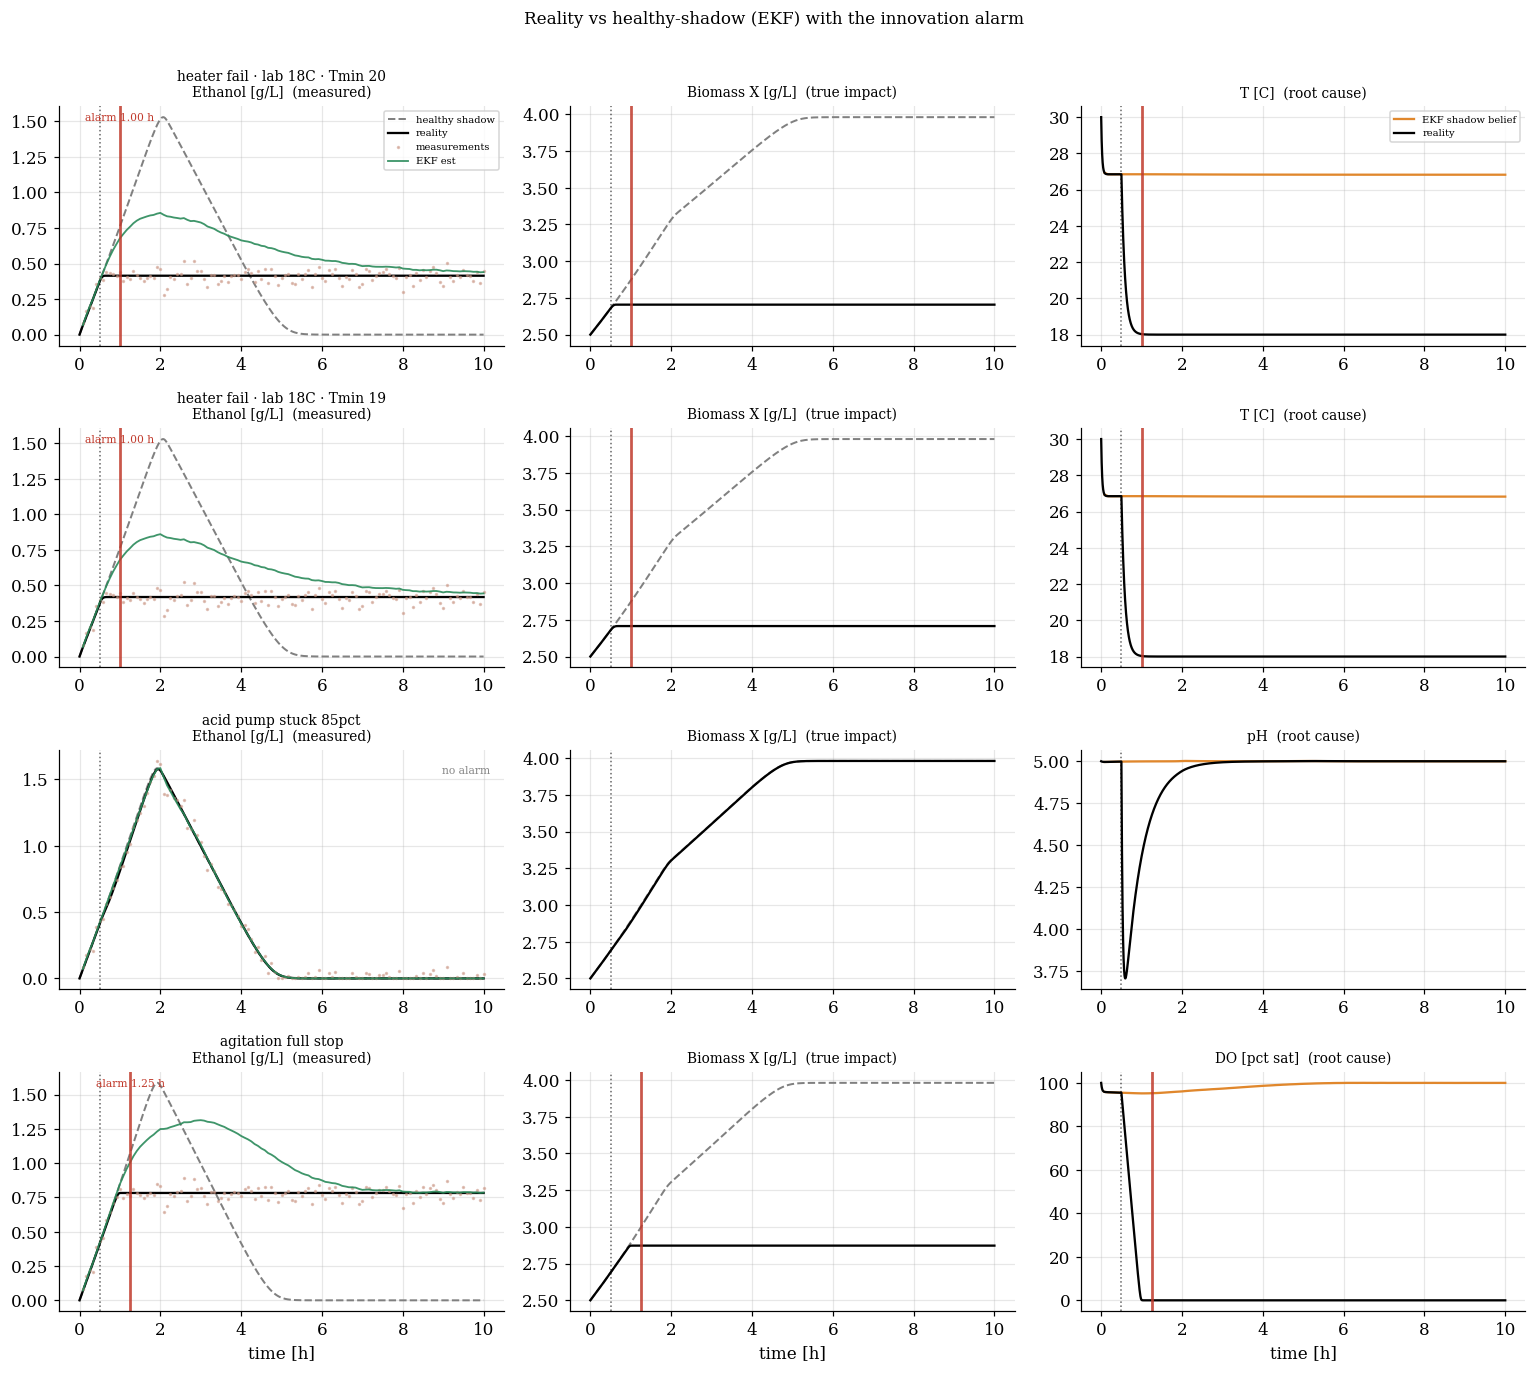

wrote figures/fault_detection_scenarios.png


In [11]:
fig, ax = plt.subplots(len(SC), 3, figsize=(14, 3.1*len(SC)))
for i, r in enumerate(SC):
    tf = r['fault']['t_fault']; al = r['alarm']
    envlabel, envidx = r['env_row']
    def deco(a, title):
        a.axvline(tf, c='k', ls=':', lw=1, alpha=.6)
        if al is not None: a.axvline(al, c='#c0392b', lw=1.8, alpha=.85)
        a.set_title(title, fontsize=9); a.grid(alpha=.3)
    # col0 ethanol (measured): healthy expectation, reality, measurements, EKF estimate
    a = ax[i, 0]
    a.plot(r['t_h'], r['Yh'][2], '--', c='gray', lw=1.3, label='healthy shadow')
    a.plot(r['t_true'], r['Y'][2], c='k', lw=1.5, label='reality')
    a.plot(r['t_meas'], r['E'], '.', ms=2.5, c='#c98', alpha=.55, label='measurements')
    a.plot(r['t_meas'], r['est'][:, 2], c='#2a8a5a', lw=1.2, alpha=.9, label='EKF est')
    deco(a, f"{r['name']}\nEthanol [g/L]  (measured)")
    if i == 0: a.legend(fontsize=6.5, loc='upper right')
    # col1 biomass (unmeasured impact): healthy expectation vs reality
    a = ax[i, 1]
    a.plot(r['t_h'], r['Yh'][0], '--', c='gray', lw=1.3)
    a.plot(r['t_true'], r['Y'][0], c='k', lw=1.5)
    deco(a, "Biomass X [g/L]  (true impact)")
    # col2 affected env (root cause): EKF shadow belief (stays healthy) vs reality
    a = ax[i, 2]
    a.plot(r['t_meas'], r['est'][:, envidx], c='#e0872c', lw=1.5, label='EKF shadow belief')
    a.plot(r['t_true'], r['Y'][envidx], c='k', lw=1.5, label='reality')
    deco(a, envlabel + "  (root cause)")
    if i == 0: a.legend(fontsize=6.5, loc='best')
    if al is not None:
        ax[i, 0].annotate(f"alarm {al:.2f} h", (al, ax[i, 0].get_ylim()[1]*0.97),
                          color='#c0392b', fontsize=7, ha='center', va='top')
    else:
        ax[i, 0].annotate("no alarm", (0.97, 0.90), xycoords='axes fraction',
                          color='#888', fontsize=7, ha='right')
for a in ax[-1, :]: a.set_xlabel('time [h]')
fig.suptitle("Reality vs healthy-shadow (EKF) with the innovation alarm", y=1.004, fontsize=11)
fig.tight_layout(); fig.savefig(f'{FIGDIR}/fault_detection_scenarios.png', dpi=120, bbox_inches='tight'); plt.show()
print(f"wrote {FIGDIR}/fault_detection_scenarios.png")

## 9 · Residual traces (first 4 h) — healthy shadow vs acid pump stuck at 30 min

The raw material the CUSUM runs on. Two runs of the same healthy-shadow EKF, plotted on the same
scale with the same band: a **healthy** batch, and one where the **acid pump sticks fully open at
t = 30 min**. The band is $\pm 3\sigma$ with $\sigma$ measured on the *healthy* residual only, so
the threshold is never fitted to the run it judges. Everything here — $\sigma$, the threshold,
the statistics and the figure — is computed on the **first 4 h** of the batch only.

Healthy: zero-mean noise inside the band. Faulted: pH is driven down faster than the PI base pump
can compensate, growth slows, and real ethanol first *lags* the healthy prediction (residual
negative) and later *overshoots* it as the shadow's own ethanol is consumed — a sustained excursion
well outside the band. (At the §7 scenario-3 level of 85 % the base pump *does* recover pH, ethanol
self-heals, and this same plot stays inside the band — that is the compensated-fault case.)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# §9 · Residual traces (first 4 h) — healthy shadow vs acid pump stuck at 30 min
#
# The CUSUM above is the deployed detector; this is the RAW material it runs on.
# One panel per run, same y-scale, same band:
#   * healthy      -> the residual is noise around 0, inside the band
#   * acid_stuck   -> the residual leaves the band after the fault (or, if the PI
#                     base pump compensates, it does NOT — which is the point of
#                     scenario 3 and is stated in the printout rather than hidden)
# The band is +-3 sigma, with sigma measured on the HEALTHY residual only, so the
# threshold is never fitted to the faulted run it is judging.
# ─────────────────────────────────────────────────────────────────────────
T_FAULT_MIN = 30.0                       # acid pump sticks at 30 min
T_FAULT_H   = T_FAULT_MIN / 60.0
F_STUCK     = F_A_MAX

set_strain('robust')

def shadow_residual(fault, seed=1):
    """Ethanol innovation (residual) of the healthy-shadow EKF on one run."""
    _t_true, _Y, t_meas, E = make_meas(fault, seed=seed)
    est, nu, S = run_ekf_shadow(t_meas, E, Q8, R_E, P0, x0)
    return t_meas, nu, S

t_res, nu_healthy, S_healthy = shadow_residual(None)
_,     nu_fault,   S_fault   = shadow_residual({'kind': 'heater',
                                                't_fault': T_FAULT_H,
                                                'T_amb': 18.0,
                                                'cardinal_T': (20.0, 30.0, 40.0)})

# Only the first T_RES_END hours of the batch are analysed/plotted here: the fault
# signature appears well inside that window, and cutting the tail keeps the trace
# (sigma, threshold, printout and figure alike) on the part that carries it.
T_RES_END = 4.0                          # end of the residual window [h]
_win       = t_res <= T_RES_END
t_res      = t_res[_win]
nu_healthy = nu_healthy[_win]; S_healthy = S_healthy[_win]
nu_fault   = nu_fault[_win];   S_fault   = S_fault[_win]

sigma_h = float(np.std(nu_healthy))      # healthy-calibrated residual sigma [g/L]
thr     = 3.0 * sigma_h

RUNS = [("healthy shadow (no fault)",                       nu_healthy, None),
        (f"heater fault @ t = {T_FAULT_MIN:.0f} min",
                                                            nu_fault,   T_FAULT_H)]

# ── printout: the residuals themselves, then the summary ─────────────────
print(f"healthy residual sigma = {sigma_h:.4f} g/L   ->  3 sigma threshold = {thr:.3f} g/L\n")
print(f"{'t [h]':>7s} {'nu healthy [g/L]':>18s} {'nu heater-fault [g/L]':>21s}")
for k in range(len(t_res)):
    flag = "  <-- outside 3 sigma" if abs(nu_fault[k]) > thr else ""
    print(f"{t_res[k]:7.2f} {nu_healthy[k]:18.4f} {nu_fault[k]:21.4f}{flag}")

print()
for label, nu, tf in RUNS:
    post = nu[t_res >= tf] if tf is not None else nu
    n_out = int(np.sum(np.abs(nu) > thr))
    print(f"{label:42s} mean {nu.mean():+7.4f}  sd {nu.std():.4f}  "
          f"|nu|max {np.abs(nu).max():.4f}  outside 3 sigma: {n_out}/{len(nu)}"
          + (f"  post-fault mean {post.mean():+.4f}" if tf is not None else ""))

# ── figure ───────────────────────────────────────────────────────────────
ylim = 1.25 * max(thr, np.abs(nu_healthy).max(), np.abs(nu_fault).max())
fig, axs = plt.subplots(len(RUNS), 1, figsize=(13, 3.4*len(RUNS)), sharex=True)
for a, (label, nu, tf) in zip(np.atleast_1d(axs), RUNS):
    a.axhspan(-thr, thr, color='#2a8a5a', alpha=.10, label='Normal range')
    a.plot(t_res, nu, c='#e0872c', lw=1.2, label='EKF innovation')
    a.axhline(0.0, c='gray', ls='--', lw=.9)
    if tf is not None:
        a.axvline(tf, c='k', ls=':', lw=1.6, label=f'Fault at t={tf:.2f}h ({T_FAULT_MIN:.0f} min)')
    a.axhline( thr, c='#c0392b', ls='--', lw=1.2, label=f'3 sigma threshold = {thr:.3f}')
    a.axhline(-thr, c='#c0392b', ls='--', lw=1.2)
    a.set_ylim(-ylim, ylim); a.set_xlim(0, T_RES_END)
    a.set_ylabel('Innovation [g/L]'); a.set_title(label, fontsize=10)
    a.legend(fontsize=7.5, loc='center right', framealpha=.9)
np.atleast_1d(axs)[-1].set_xlabel('time [h]')
fig.tight_layout()
fig.savefig(f'{FIGDIR}/residuals_healthy_vs_heater_fault.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nwrote {FIGDIR}/residuals_healthy_vs_heater_fault.png")


---
## 10 · Adding sensors — does a T or pH probe improve the alarm?

The ethanol-only shadow misses *growth-silent* / *controller-compensated* faults (§9). Now we
let the EKF also **measure** an environment variable — T or pH — as a noisy channel
($\sigma=0.05$, every 5 min), exactly like ethanol.

In [13]:
sT, spH = 0.05, 0.05                                  # T, pH sensor noise (user spec)
# name -> (state index, R the filter assumes). Ethanol carries the app's inflated R;
# T and pH are given their true variance, which is why their k/h are derived rather
# than copied (see the note above).
CH = {'E': (2, R_E), 'T': (5, sT**2), 'pH': (6, spH**2)}

def run_ekf_multi(t_meas, meas, chan_idx, R_diag, Q8, P0, x0):
    """Healthy-shadow EKF with an arbitrary set of measured channels (chan_idx into the state).
    meas[k] is the measurement vector at t_meas[k] (same order as chan_idx).
    Returns est[len,8], per-channel innovations nu[len,n_chan] and their predicted
    variances S[len,n_chan] (the diagonal of H P H^T + R, which is what each
    channel's own CUSUM normalises by)."""
    x = x0.copy(); P = P0.copy(); integ = 0.0
    m = len(chan_idx); H = np.zeros((m, 8))
    for r, ci in enumerate(chan_idx): H[r, ci] = 1.0
    R = np.diag(R_diag)
    out = np.zeros((len(t_meas), 8)); nu = np.zeros((len(t_meas), m))
    Sa = np.zeros((len(t_meas), m)); t_prev = 0.0
    for k, tm in enumerate(t_meas):
        n = max(1, int(np.ceil((tm - t_prev) / DT_PRED))); h = (tm - t_prev) / n
        for i in range(n):
            F_A, F_B, err, u = pi_pumps(x[6], integ)
            sat = u > F_B_MAX or u < -F_A_MAX
            if not (sat and (err > 0.0) == (u > 0.0)): integ += err * h
            f = lambda yy: rhs8_ctrl(yy, integ)
            k1 = f(x); k2 = f(x + h/2*k1); k3 = f(x + h/2*k2); k4 = f(x + h*k3)
            x = x + h/6*(k1 + 2*k2 + 2*k3 + k4)
            x[0]=max(x[0],0); x[1]=max(x[1],0); x[2]=max(x[2],0); x[7]=max(x[7],0)
            P = prop_cov(P, fd_jac(f, x), Q8, h)
        x, P, innov, S = correct(x, P, H, R, meas[k])
        out[k] = x; nu[k] = innov.ravel(); Sa[k] = np.diag(S); t_prev = tm
    return out, nu, Sa

def gen_meas(fault, seed):
    """Noisy measurements of E, T, pH at 5-min cadence from the (faulted) truth."""
    t_true, Y = run_truth(fault)
    tm = np.arange(DT_MEAS, T_FINAL + 1e-9, DT_MEAS); rng = np.random.default_rng(seed)
    d = {'E':  np.maximum(np.interp(tm, t_true, Y[2]) + rng.normal(0, SIGMA_E_SENSOR, len(tm)), 0.0),
         'T':  np.interp(tm, t_true, Y[5]) + rng.normal(0, sT,  len(tm)),
         'pH': np.interp(tm, t_true, Y[6]) + rng.normal(0, spH, len(tm))}
    return t_true, Y, tm, d

# The app's constants expressed as a RULE — k = 1 sigma, h = 10 sigma of the channel's
# own healthy spread. On ethanol this reproduces 0.15 / 1.5 (healthy sd(z) ~ 0.14);
# on an honestly-normalised channel it lands near 1.0 / 10.0. Same detector, same
# false-alarm guarantee, ported instead of copied.
K_SIGMA, H_SIGMA = K_SLACK / 0.1506, H_CUSUM / 0.1506     # = 1.0 sigma, 10.0 sigma

_KH = {}
def kh_multi(chans, card, Ta, strain, nseed=8):
    """Per-channel (k, h), from each channel's healthy spread in this lab config."""
    key = (tuple(chans), card, Ta, strain)
    if key in _KH: return _KH[key]
    idx = [CH[c][0] for c in chans]; R = [CH[c][1] for c in chans]
    zs = [[] for _ in chans]
    for s in range(nseed):
        with scenario_env(Ta, card):
            if card is None: set_strain(strain)
            _, _, tm, d = gen_meas(None, 300 + s)
            _, nu, S = run_ekf_multi(tm, np.column_stack([d[c] for c in chans]), idx, R, Q8, P0, x0)
        for j in range(len(chans)):
            zs[j].append(nu[:, j] / np.sqrt(S[:, j]))
    sd = np.array([np.std(np.concatenate(z)) for z in zs])
    k_arr, h_arr = K_SIGMA * sd, H_SIGMA * sd
    # Ethanol keeps the app's LITERAL constants — it is the channel they were tuned
    # on, and deriving them again would give a second, slightly different ethanol
    # detector inside the same notebook. Only the honestly-normalised T/pH channels
    # need the rule.
    for j, c in enumerate(chans):
        if c == 'E':
            k_arr[j], h_arr[j] = K_SLACK, H_CUSUM
    _KH[key] = (k_arr, h_arr)
    return _KH[key]

def multi_alarm(t_meas, z, kh, names):
    """First channel whose CUSUM crosses its own h. Returns (alarm_t, channel)."""
    k_arr, h_arr = kh
    first, who = None, None
    for j in range(z.shape[1]):
        _, _, a = cusum_alarm(t_meas, z[:, j], k_arr[j], h_arr[j])
        if a is not None and (first is None or a < first):
            first, who = a, names[j]
    return first, who

def run_one(chans, fault, card, Ta, strain, seed=1):
    idx = [CH[c][0] for c in chans]; R = [CH[c][1] for c in chans]
    kh = kh_multi(chans, card, Ta, strain)
    with scenario_env(Ta, card):
        if card is None: set_strain(strain)
        t_true, Y, tm, d = gen_meas(fault, seed)
        est, nu, S = run_ekf_multi(tm, np.column_stack([d[c] for c in chans]), idx, R, Q8, P0, x0)
    z = nu / np.sqrt(S)
    al, who = multi_alarm(tm, z, kh, chans)
    return dict(chans=chans, kh=kh, t_true=t_true, Y=Y, tm=tm, d=d, est=est,
                nu=nu, S=S, z=z, alarm=al, who=who)

# the four scenarios from §7, as (name, fault, cardinal_T, T_amb, strain)
BASE = [("heater fail Tmin20", {'kind':'heater','t_fault':0.5}, (20.,30.,40.), 18., None),
        ("heater fail Tmin19", {'kind':'heater','t_fault':0.5}, (19.,30.,40.), 18., None),
        ("acid stuck 85pct",   {'kind':'acid_stuck','t_fault':0.5,'F_stuck':0.85*F_A_MAX}, None, 22., 'robust'),
        ("agitation full stop",{'kind':'aeration','t_fault':0.5,'N_rpm':0.0}, None, 22., 'robust')]

def sensor_study(add, scenarios):
    print(f"{'scenario':22s} {'ethanol only':>16s} {'ethanol+'+add:>16s}")
    rows = []
    for nm, fault, card, Ta, strain in scenarios:
        rE = run_one(['E'], fault, card, Ta, strain)
        rX = run_one(['E', add], fault, card, Ta, strain)
        fmt = lambda r: (f"{r['who']} {r['alarm']:.2f}h" if r['alarm'] else "MISS")
        print(f"{nm:22s} {fmt(rE):>16s} {fmt(rX):>16s}")
        rows.append((nm, rE, rX))
    return rows

def study_figure(rows, add, add_idx, focus, ttl):
    """3 panels for the focus scenario, each from the RIGHT run:
    (0) the env var — reality vs the ethanol-only shadow belief (stays healthy) + noisy meas;
    (1) the ETHANOL-ONLY CUSUM arms (never reach h -> misses); (2) the ETHANOL+add channel's
    own CUSUM arms (cross h -> alarm). Panels 1 and 2 come from different filters on purpose."""
    import matplotlib.pyplot as plt
    nm, rE, rX = next(x for x in rows if x[0] == focus)
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
    # (0) root-cause variable: reality vs the pure (ethanol-only) shadow belief
    ax[0].plot(rX['t_true'], rX['Y'][add_idx], c='k', lw=1.5, label='reality')
    ax[0].plot(rE['tm'], rE['est'][:, add_idx], c='#e0872c', lw=1.5, label='shadow belief (healthy)')
    ax[0].plot(rX['tm'], rX['d'][add], '.', ms=3, c='#8ab', alpha=.5, label=f'{add} measurements')
    ax[0].set_title(f"{focus}\n{add} : reality vs shadow"); ax[0].legend(fontsize=7)
    def arms(a, r, j, colour, title):
        Sp, Sn = cusum(r['z'][:, j], r['kh'][0][j]); h = r['kh'][1][j]
        a.plot(r['tm'], Sp, c=colour, lw=1.3, ls='--', label='S+')
        a.plot(r['tm'], Sn, c=colour, lw=1.6, label='S- (fault direction)')
        a.axhline(h, c='k', ls='--', lw=.8)
        a.annotate(f"h = {h:.2f}", (r['tm'][-1], h), fontsize=7, va='bottom', ha='right')
        a.set_title(title); a.legend(fontsize=7)
    # (1) ethanol-only -> misses
    arms(ax[1], rE, 0, '#2a8a5a',
         f"ethanol-only CUSUM\n({'MISS' if rE['alarm'] is None else rE['who']+' '+format(rE['alarm'],'.2f')+'h'})")
    # (2) the added channel's own CUSUM -> alarm
    arms(ax[2], rX, 1, '#c0392b', f"ethanol+{add}: the {add} CUSUM")
    if rX['alarm']:
        ax[2].axvline(rX['alarm'], c='#c0392b', lw=1.6)
        # top of the axes, not on the h line — the two labels collide down there
        ax[2].annotate(f"alarm {rX['alarm']:.2f}h ({rX['who']})", (0.97, 0.72),
                       xycoords='axes fraction', color='#c0392b', fontsize=8, ha='right')
    for a in ax: a.axvline(0.5, c='k', ls=':', alpha=.5); a.set_xlabel('time [h]'); a.grid(alpha=.3)
    fig.suptitle(ttl, y=1.02, fontsize=11); fig.tight_layout(); return fig

## 11 · pH sensor  —  catches the pump faults ethanol misses

Run the four §7 scenarios **plus a dead base pump** (`base_off`: pH drifts down uncompensated —
growth barely moves, so ethanol shrugs). Compare **ethanol-only** vs **ethanol + pH**.

scenario                   ethanol only       ethanol+pH
heater fail Tmin20              E 1.00h          E 1.00h
heater fail Tmin19              E 1.00h          E 1.00h
acid stuck 85pct                   MISS         pH 0.58h
agitation full stop             E 1.25h          E 1.25h
base pump off                      MISS         pH 1.42h


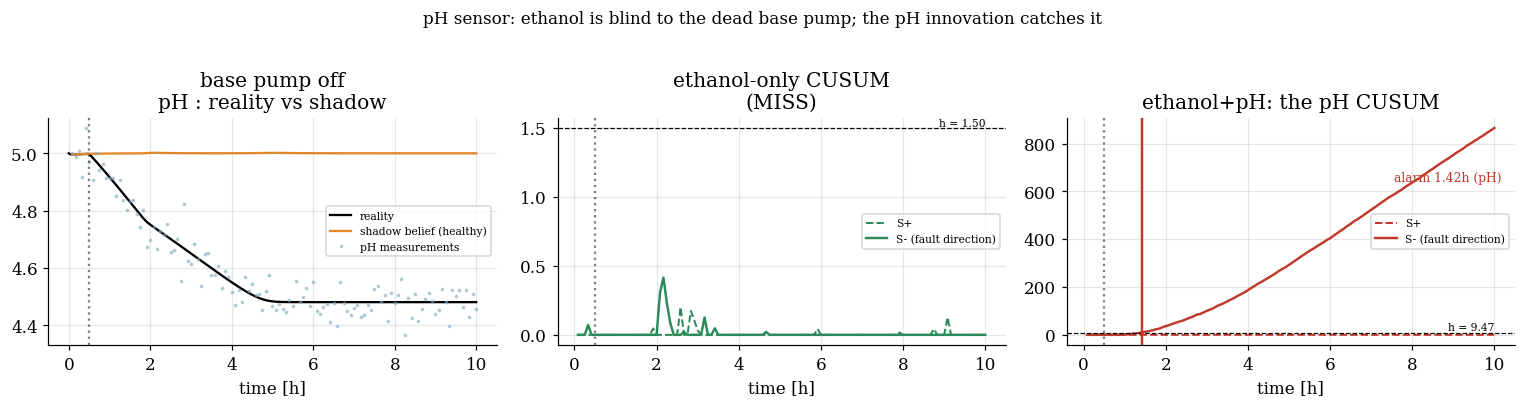

wrote figures/sensor_pH_study.png


In [14]:
rows_pH = sensor_study('pH', BASE + [("base pump off", {'kind':'base_off','t_fault':0.5}, None, 22., 'robust')])
fig = study_figure(rows_pH, 'pH', 6, "base pump off",
                   "pH sensor: ethanol is blind to the dead base pump; the pH innovation catches it")
fig.savefig(f'{FIGDIR}/sensor_pH_study.png', dpi=120, bbox_inches='tight'); plt.show(); print(f"wrote {FIGDIR}/sensor_pH_study.png")

## 12 · Temperature sensor  —  faster on heater faults, and catches the transient blip

Run the four §7 scenarios **plus a transient heater outage** (fails at 0.5 h, **recovers at 0.6 h**;
$T_{\min}=T_{\text{lab}}=18$) — a 6-minute dip too brief to dent ethanol. Compare **ethanol-only**
vs **ethanol + T**.

scenario                   ethanol only        ethanol+T
heater fail Tmin20              E 1.00h          T 0.58h
heater fail Tmin19              E 1.00h          T 0.58h
acid stuck 85pct                   MISS             MISS
agitation full stop             E 1.25h          E 1.33h
heater blip 0.5-0.6                MISS          T 0.58h


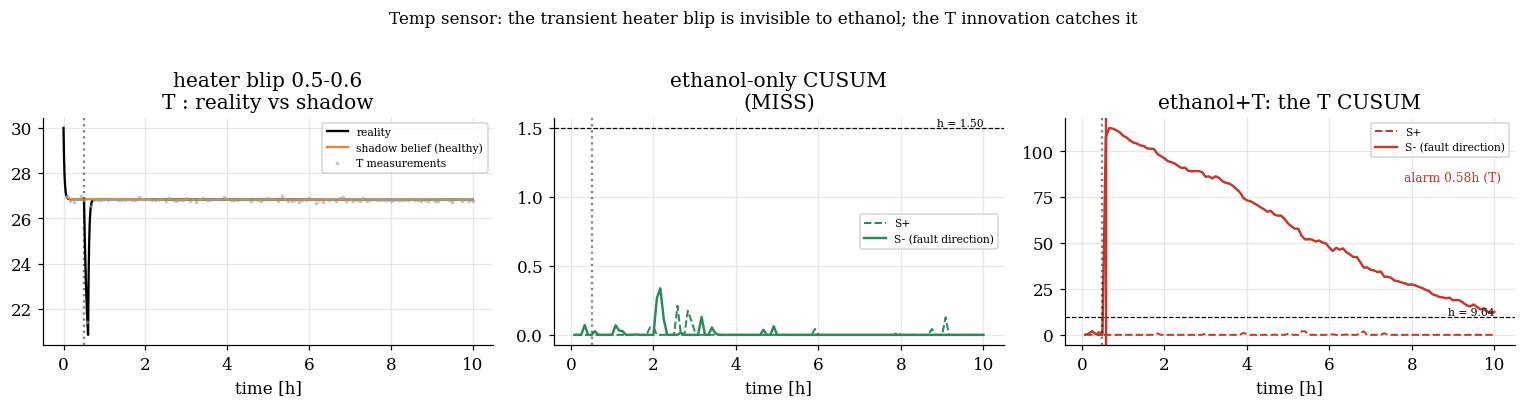

wrote figures/sensor_T_study.png


In [15]:
rows_T = sensor_study('T', BASE + [("heater blip 0.5-0.6",
                                    {'kind':'heater','t_fault':0.5,'t_recover':0.6}, (18.,30.,40.), 18., None)])
fig = study_figure(rows_T, 'T', 5, "heater blip 0.5-0.6",
                   "Temp sensor: the transient heater blip is invisible to ethanol; the T innovation catches it")
fig.savefig(f'{FIGDIR}/sensor_T_study.png', dpi=120, bbox_inches='tight'); plt.show(); print(f"wrote {FIGDIR}/sensor_T_study.png")

## 13 · Findings — what the T and pH sensors buy

- **Each sensor closes the gap on its own fault family.** The **pH** probe catches the *dead base
  pump* (`base_off`) and the *compensated acid-stuck* fault — both **missed** by ethanol alone —
  because a pH fault leaves ethanol nearly untouched but moves pH by ~1 pH unit. The **T** probe
  catches thermal faults **faster** (0.58 h vs 1.00 h on ethanol) and catches the **transient
  heater blip** that ethanol never sees (too brief to change the integrated ethanol).
- **A sensor only helps its own channel.** Adding **T** does *not* catch the acid-pump fault, and
  adding **pH** does *not* catch the heater blip — the innovation only carries a fault that
  actually moves that measured variable. *Measure what you need to detect.* (Same "state-specific
  sensors" lesson as the generalization study.)
- **Detection also localizes.** The alarm now reports *which* channel fired (T / pH / ethanol),
  which points straight at the fault family — the L-a-style diagnostic the ethanol-only detector
  could not give.


**Conclusion for the instrumentation question:** for *state estimation* in healthy operation the
T/pH sensors add little (the earlier sensor-value study). For **fault detection** they are clearly
worth it — each one converts a whole family of missed/late faults into fast, localized alarms.


**Next:** notebook 7 (`7_mmae_fault_isolation.ipynb`) takes the alarm as given and asks *which*
fault fired it — a bank of EKFs, one per candidate cause, scored by Bayes over their innovations.